# Kodowanie dyskretnych problemów optymalizacyjnych za pomocą QUBO / Isinga.



## Problem podziału grafu

Rozważmy graf prosty $G = (V, E)$ z parzystą liczbą wierzchołków $N = \vert V \vert$. Naszym celem jest znalezienie takiego podziału wierzchołków na dwa równe podzbiory rozmiaru $\frac{N}{2}$ takie, że liczba krawędzi je łączących jest minimalna.

In [ ]:
import networkx as nx
from dimod import BinaryQuadraticModel, ExactSolver
from pyqubo import Array

brute_force = ExactSolver()

graph = nx.erdos_renyi_graph(n=6, p=0.3, seed=2137)

# tworzymy model
spins = Array.create("spins", shape=graph.number_of_nodes(), vartype="SPIN")

H1 = sum([s for s in spins])**2 
H2 = sum([1 - spins[i]*spins[j] for i,j in graph.edges()])
H = sum([H1, H2])

model = H.compile()

linear, quadratic, offset = model.to_ising()

#rozwiązujemy problem
bqm = BinaryQuadraticModel(linear, quadratic, offset, vartype="SPIN")
sampleset = brute_force.sample(bqm)
print(sampleset.lowest(0))

  spins[0] spins[1] spins[2] spins[3] spins[4] spins[5] energy num_oc.
0       +1       +1       +1       -1       -1       -1    4.0       1
1       -1       -1       -1       +1       +1       +1    4.0       1
['SPIN', 2 rows, 2 samples, 6 variables]


## Problem pełnego pokrycia

Rożważmy zbiór $U = \{1, \ldots, n \}$, oraz podzbiory $V_i \subseteq U$, $i = 1, \ldots, N$ takie, że:

$$
U = \bigcup_i V_i.
$$

Pytanie brzmi, czy istnieje zbiór podzbiorów $R = \{V_i\} taki, że elementy $R$ są rozłącznymi zbiorami tj. $V_i \cap V_j = \emptyset$, $\forall_{V_i, V_j \in R}$ oraz suma elementów $R$ stanowi $U$? Innymi słowy:

$$
\bigcup_{V \in R} V = U
$$


In [62]:
import numpy as np
from dimod import BinaryQuadraticModel, ExactSolver
from pyqubo import Array


brute_force = ExactSolver()
rng = np.random.default_rng(seed=42)

def random_subset(s):
    return {x for x in s if rng.choice((True, False))}


n = 4
N = 5

U = set(range(1, n+1))
R = [random_subset(U) for i in range(N)]

x = Array.create("x", shape=N, vartype="BINARY")
H = sum([(1 - sum([x[i] if a in R[i] else 0 for i in range(N)]))**2 for a in U])
model = H.compile()
qubo, offset = model.to_qubo()

bqm = BinaryQuadraticModel(qubo, offset=offset, vartype="BINARY")
sampleset = brute_force.sample(bqm)

print(sampleset.lowest(0))

  x[0] x[1] x[2] x[4] energy num_oc.
0    0    1    0    1    0.0       1
['BINARY', 1 rows, 1 samples, 4 variables]


## Przykład - zapisanie problemu MAX-CUT jako QUBO (Zadanie Domowe)

Problem Max Cut jest jednym z najbardziej znanych problemów optymalizacji kombinatorycznej. Dla danego grafu nieskierowanego $G(V,E)$ ze zbiorem wierzchołków  $V$ oraz zbiorem krawędzi  $E$, problem Max Cut polega na podziale zbioru  $V$ na dwa podzbiory, $S$, $T$, $S \cup T = V$, tak aby liczba krawędzi łączących te podzbiory (tzw. przeciętych przez cięcie) była jak największa.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Utwórz graf
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_edges_from([
    (1, 2),  # krawędź górna
    (1, 3),  # krawędź pionowa lewa
    (2, 4),  # krawędź pionowa prawa
    (3, 4),  # krawędź środkowa pozioma
    (3, 5),  # przekątna lewa
    (4, 5),  # przekątna prawa
])

# Stałe pozycje węzłów dla powtarzalnego układu
pos = {
    1: (0.0,  1.0),
    2: (1.0,  1.0),
    3: (0.0,  0.0),
    4: (1.0,  0.0),
    5: (0.5, -1.0),
}

# Definicja trzech rozcięć (zbiory S) wraz z tytułami
cuts = [
    ({3, 4, 5}, "Rozmiar cięcia: 2"),
    ({4},       "Rozmiar cięcia: 3"),
    ({1, 4},    "Rozmiar cięcia: 5"),
]

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
for ax, (S, title) in zip(axes, cuts):
    T = set(G.nodes()) - S
    # Podział krawędzi na: wewnątrz S, wewnątrz T oraz krawędzie cięcia
    edges_inside_S = [(u, v) for u, v in G.edges() if u in S and v in S]
    edges_inside_T = [(u, v) for u, v in G.edges() if u in T and v in T]
    edges_cut      = [(u, v) for u, v in G.edges() if (u in S) ^ (v in S)]

    # Rysuj węzły: niebieskie jeśli w S, białe w przeciwnym wypadku
    node_colors = ["tab:blue" if n in S else "white" for n in G.nodes()]
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=G.nodes(),
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2,
        node_size=800,
        ax=ax
    )
    nx.draw_networkx_labels(
        G, pos,
        labels={n: str(n) for n in G.nodes()},
        font_color="black",
        font_size=12,
        ax=ax
    )

    # Rysuj krawędzie wewnątrz T 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_inside_T,
        style="solid",
        edge_color="black",
        width=2.0,
        ax=ax
    )
    # Rysuj krawędzie wewnątrz S 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_inside_S,
        style="solid",
        edge_color="black",
        width=2.0,
        ax=ax
    )
    # Rysuj krawędzie cięcia 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges_cut,
        style="dashed",
        edge_color="black",
        width=2.0,
        ax=ax
    )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

plt.tight_layout()
plt.show()


Problem ten można zamodelować za pomocą zmiennych binarnych, gdzie $x_i = 1$, jeśli wierzchołek $i$ należy do jednego podzbioru oraz $x_i = 0$, gdy należy do drugiego. Krawędź $(i,j)$ jest przecięta przez cięcie (tzn. jej końce znajdują się w różnych podzbiorach), co opisuje wyrażenie $x_i + x_j - 2x_i x_j$.

W związku z tym problem maksymalizacji liczby krawędzi w cięciu można zapisać następująco:
$$
\max \sum_{(i,j)\in G}(x_i + x_j - 2x_i x_j) = \min \sum_{(i,j)\in G}(-x_i - x_j + 2x_i x_j)
$$

In [ ]:
# Przykład grafu losowego na 15 wierzchołkach
import numpy as np
import networkx as nx

graph = nx.erdos_renyi_graph(n=15, p=0.6, seed=42)
nx.draw(graph, with_labels=True)

In [ ]:
# Rozwiązanie problemu
from collections import defaultdict
from math import inf
from itertools import product

Q = defaultdict(int)
for i, j in graph.edges:
    Q[(i,i)]+= -1
    Q[(j,j)]+= -1
    Q[(i,j)]+= 2

qubo = BinaryQuadraticModel(Q, "BINARY")
n = qubo.num_variables

best_energy = inf
best_state = []
for state in product([0, 1], repeat=n):
    x = np.array(state)
    energy = qubo.energy(x)
    if energy < best_energy:
        best_energy = energy
        best_state = state


# Interpretacja wyników
S0 = [node for node in graph.nodes if not best_state[node]]
S1 = [node for node in graph.nodes if best_state[node]]


uncut_edges = [(u, v) for u, v in graph.edges if best_state[u]==best_state[v]]

# narysowanie najlepszego znalezionego wyniku
nx.draw(graph, node_color=["r" if i in S0 else "c" for i in list(graph.nodes)], with_labels=True, 
       edge_color=["black" if e in uncut_edges else "lightgray" for e in list(graph.edges)])

## Rozwiązania

$$
H = H_{rowne} + H_{min}
$$

$$
H_{rowne} = \left( \sum_{i = 1}^N s_i \right)^{2}
$$

$$
H_{min} = \sum_{(u,v) \in E} (1 - s_u s_v)
$$
$h = 0$ i $J = 2$ na krawedziach które nie istnieja i 1 na krawedziach ktore istnieja


$$
H = \sum_{\alpha = 1}^n \left( 1 - \sum_{i: \alpha \in V_i} x_i \right)^2
$$
$-n$ na przekątnhych i $2 \times$ moc przekroju na pozostałych elementach

[[-4.  2.  2.  0.  2.]
 [ 2. -4.  2.  0.  0.]
 [ 2.  2. -4.  0.  2.]
 [ 0.  0.  0. -4.  0.]
 [ 2.  0.  2.  0. -4.]]
x =  (0, 1, 0, 1, 1)
R = [{1, 4}, {1, 3}, {1, 2}, set(), {2, 4}]


'Pełne pokrycie'

-8.0
(1, 1, 1, -1, -1, -1)


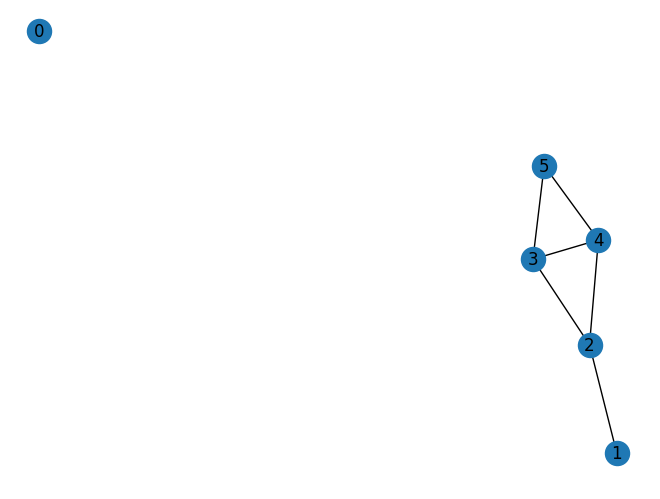